## Setup — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
folder_path = '/content/drive/MyDrive/ecommerce_dataset'
for file in os.listdir(folder_path):
    print(file)

users.csv
order_items.csv
products.csv
reviews.csv
orders.csv
events.csv


## Load Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

folder_path = '/content/drive/MyDrive/ecommerce_dataset'

users       = pd.read_csv(f'{folder_path}/users.csv')
orders      = pd.read_csv(f'{folder_path}/orders.csv')
order_items = pd.read_csv(f'{folder_path}/order_items.csv')
products    = pd.read_csv(f'{folder_path}/products.csv')
reviews     = pd.read_csv(f'{folder_path}/reviews.csv')
events      = pd.read_csv(f'{folder_path}/events.csv')

# Quick check
for name, df in [('users',users),('orders',orders),('order_items',order_items),
                 ('products',products),('reviews',reviews),('events',events)]:
    print(f"{name}: {list(df.columns)}")

users: ['user_id', 'name', 'email', 'gender', 'city', 'signup_date']
orders: ['order_id', 'user_id', 'order_date', 'order_status', 'total_amount']
order_items: ['order_item_id', 'order_id', 'product_id', 'user_id', 'quantity', 'item_price', 'item_total']
products: ['product_id', 'product_name', 'category', 'brand', 'price', 'rating']
reviews: ['review_id', 'order_id', 'product_id', 'user_id', 'rating', 'review_text', 'review_date']
events: ['event_id', 'user_id', 'product_id', 'event_type', 'event_timestamp']


## Build Master DataFrame

Merge orders → users → order_items → products → reviews.  
`events` is kept separate to avoid row explosion (one user-product pair can have many events).

In [4]:
# Step 1: orders + users
df = pd.merge(orders, users, on='user_id', how='left')


# Step 2: + order_items  →  resolves user_id_x / user_id_y
df = pd.merge(df, order_items, on='order_id', how='left')
df = df.drop(columns=['user_id_y'])
df = df.rename(columns={'user_id_x': 'user_id'})

# Step 3: + products
df = pd.merge(df, products, on='product_id', how='left')

# Step 4: + reviews  →  resolves product_id_x/y and rating_x/y
df = pd.merge(df, reviews, on=['order_id', 'product_id'], how='left')
df = df.drop(columns=['user_id_y', 'rating_y'])
df = df.rename(columns={'user_id_x': 'user_id', 'rating_x': 'rating'})
df=df.merge(events, on=['user_id', 'product_id'], how='left')

#

# Standardise column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.shape)
print(df.columns.tolist())



(43538, 26)
['order_id', 'user_id', 'order_date', 'order_status', 'total_amount', 'name', 'email', 'gender', 'city', 'signup_date', 'order_item_id', 'product_id', 'quantity', 'item_price', 'item_total', 'product_name', 'category', 'brand', 'price', 'rating', 'review_id', 'review_text', 'review_date', 'event_id', 'event_type', 'event_timestamp']


## Data Types & Null Check

In [5]:
# Convert date columns
df[['signup_date', 'order_date', 'review_date']] = (
    df[['signup_date', 'order_date', 'review_date']].apply(pd.to_datetime)
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43538 entries, 0 to 43537
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         43538 non-null  object        
 1   user_id          43538 non-null  object        
 2   order_date       43538 non-null  datetime64[ns]
 3   order_status     43538 non-null  object        
 4   total_amount     43538 non-null  float64       
 5   name             43538 non-null  object        
 6   email            43538 non-null  object        
 7   gender           43538 non-null  object        
 8   city             43538 non-null  object        
 9   signup_date      43538 non-null  datetime64[ns]
 10  order_item_id    43538 non-null  object        
 11  product_id       43538 non-null  object        
 12  quantity         43538 non-null  int64         
 13  item_price       43538 non-null  float64       
 14  item_total       43538 non-null  float

In [6]:
# Nulls are structural — result of left joins (e.g. users with no reviews)
# Strategy: filter per analysis, not global drop
df.isna().sum()

,0
order_id,0
user_id,0
order_date,0
order_status,0
total_amount,0
name,0
email,0
gender,0
city,0
signup_date,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['order_status'].unique()

array(['processing', 'completed', 'cancelled', 'returned', 'shipped'],
      dtype=object)

## Remove Incomplete Month

Nov 2025 has partial data — exclude it from trend analyses.

In [9]:
df['month_year'] = df['order_date'].dt.to_period('M')
df = df[df['month_year'] != '2025-11']

## Total Revenue (Completed + Shipped Orders)

In [10]:
total_revenue = (
    df[df['order_status'].isin(['completed', 'shipped'])]
    .drop_duplicates(subset='order_id')['total_amount']
    .sum()
)
completed_orders= (
    df[df['order_status'].isin(['completed', 'shipped'])]
    .drop_duplicates(subset='order_id')['order_id']
    .count()
)
order_not_completed = (
    df[df['order_status'].isin(['cancelled', 'returned'])]
    .drop_duplicates(subset='order_id')['order_id']
    .count()
)
print('no. of successful orders',completed_orders)
print('no. of unsuccessful orders',order_not_completed)
print(f"Total Revenue: ₹{total_revenue:,.2f}")

no. of successful orders 7972
no. of unsuccessful orders 7837
Total Revenue: ₹4,723,770.74


> **Insight:** Total revenue from completed and shipped orders is **₹47,23,771**. Cancelled and returned orders together account for roughly the same count as completed ones (~7800), suggesting nearly 40% of orders never reach the customer — worth investigating fulfillment or product quality issues.

## Monthly Revenue Trend

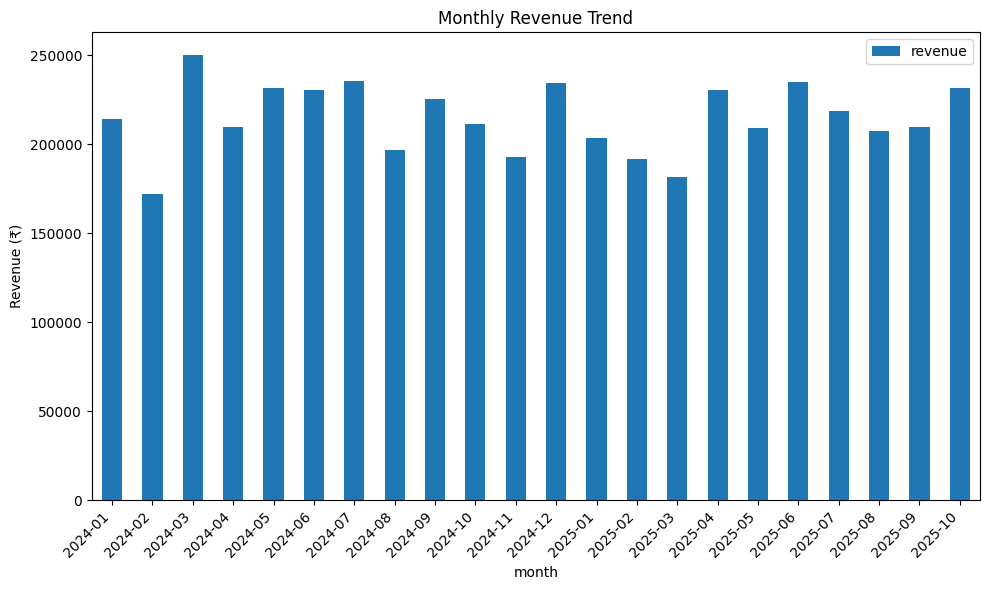

In [11]:
monthly_revenue = (
    df[df['order_status'].isin(['completed', 'shipped'])]
    .drop_duplicates(subset='order_id')
    .groupby('month_year')['total_amount']
    .sum()
    .reset_index()
)
monthly_revenue.columns = ['month', 'revenue']
# Sort by month for correct time-series order
monthly_revenue = monthly_revenue.sort_values('month')

monthly_revenue.plot(x='month', y='revenue', kind='bar', figsize=(10, 6))
plt.ticklabel_format(style='plain', axis='y')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** Revenue peaked in **March 2024 (₹2,50,383)** and was lowest in **February 2024 (₹1,71,917)**. The overall trend is relatively flat month-on-month with no strong growth signal, which suggests customer acquisition and retention efforts may need attention.\
And festive months should generate more revenue so need some pricing and offer review for better bussiness and more new customers



## Dataset Overview

In [12]:
df.agg({
    'user_id':    'nunique',
    'product_id': 'nunique',
    'category':   'nunique',
    'order_id':   'nunique',
    'brand':      'nunique',
})

,0
user_id,8594
product_id,2000
category,10
order_id,19611
brand,12


> **Insight:** The dataset covers **8,594 users**, **19,611 orders**, **2,000 products** across **10 categories** and **12 brands**. With ~2.3 orders per user on average, the platform has reasonable order frequency but a wide product catalogue relative to its brand count.

In [13]:
# Rows where a user exists but order_status is null
df[(df['user_id'].notna()) & (df['order_status'].isna())]

,order_id,user_id,order_date,order_status,total_amount,name,email,gender,city,signup_date,...,brand,price,rating,review_id,review_text,review_date,event_id,event_type,event_timestamp,month_year


## Top 25 Customers by Number of Orders

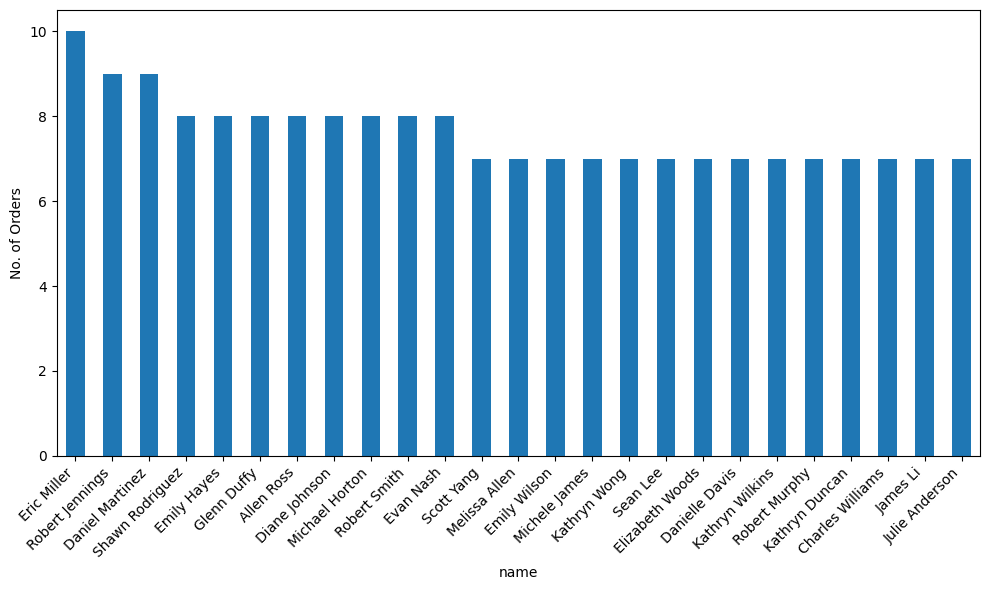

In [14]:
top_customers = (
    df.groupby(['user_id', 'name'])['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(25)
)
# Use only the name level for a readable x-axis
top_customers.index = top_customers.index.get_level_values('name')
top_customers.plot(ylabel='No. of Orders', kind='bar', figsize=(10, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** The top 25 customers each placed between **7 and 10 orders** — a fairly narrow range, suggesting the platform's most engaged users have a natural ceiling on purchase frequency. No single power user is dramatically outlying the group.

## Average Order Value (AOV)

In [15]:
completed_orders = (
    df[df['order_status'].isin(['completed', 'shipped'])]
    .drop_duplicates(subset='order_id')
)
# Both numerator and denominator use the same filtered set
aov = completed_orders['total_amount'].sum() / completed_orders['order_id'].nunique()
print(f"Average Order Value: ₹{aov:,.2f}")

Average Order Value: ₹592.55


> **Insight:** Average Order Value is **₹592.55**. This is the baseline for measuring upsell and cross-sell effectiveness — strategies like product bundling or 'frequently bought together' could push this upward.

## User Conversion Rate

In [16]:
active_buyers = df[df['order_status'].isin(['processing', 'completed', 'shipped'])]['user_id'].nunique()
total_users   = df['user_id'].nunique()

print(f"Total users:   {total_users}")
print(f"Active buyers: {active_buyers}")
print(f"Conversion %:  {(active_buyers / total_users) * 100:.2f}%")

Total users:   8594
Active buyers: 6905
Conversion %:  80.35%


> **Insight:** **80.3% of registered users** (6,905 out of 8,594) have placed at least one order — an exceptionally high conversion rate. This means the platform's signup-to-purchase funnel is working well. Focus should shift to increasing order frequency and basket size rather than acquiring new users.

## Top 10 Products by Revenue

Top 10 Products:
product_name
Orion Coach        100937.71
Willow Result       93309.28
Acme Room           86651.34
Astra Pull          81654.62
NeoTech Guess       78103.53
Nimbus Word         77182.93
Harbor Onto         74854.66
Pulse Money         74335.16
Willow Hospital     72255.95
GreenLeaf Item      70357.95
Name: total_amount, dtype: float64

Top 10 Revenue:    ₹809,643.13
Total Revenue:     ₹33,403,648.80
Contribution %:    2.42%


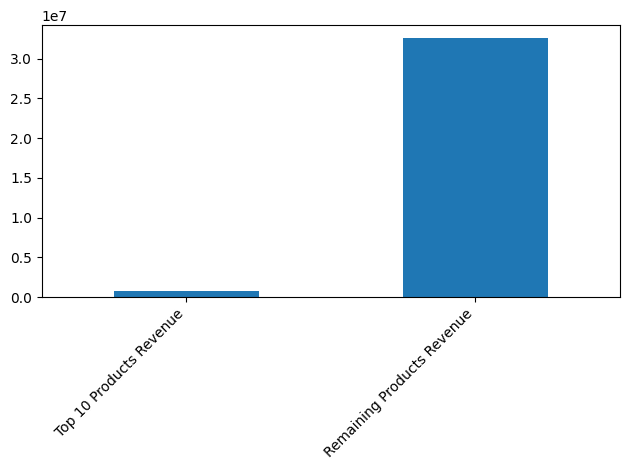

In [17]:
top10_products = (
    df.groupby('product_name')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

total_rev    = df['total_amount'].sum()
top10_rev    = top10_products.sum()
contribution = (top10_rev / total_rev) * 100

print(f"Top 10 Products:\n{top10_products}")
print(f"\nTop 10 Revenue:    ₹{top10_rev:,.2f}")
print(f"Total Revenue:     ₹{total_rev:,.2f}")
print(f"Contribution %:    {contribution:.2f}%")

pd.Series({
    'Top 10 Products Revenue':    top10_rev,
    'Remaining Products Revenue': total_rev - top10_rev
}).plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** The top 10 products contribute only **2.4% of total revenue**, with the highest single product (Orion Coach) at ₹1,00,938. Revenue is very evenly distributed across the 2,000-product catalogue — there are no dominant blockbuster products. This is a long-tail revenue model.

## Top 10% Customers by Revenue

no. of customers in top 10% 859
their contribution in total revenue 33.522077666577815 %


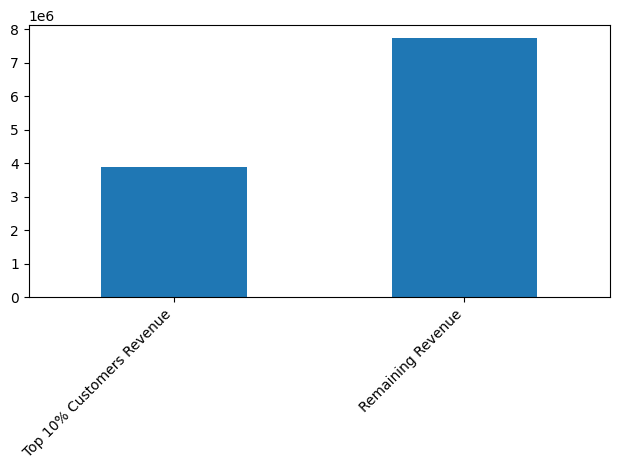

In [18]:
top_n = int(df['user_id'].nunique() / 10)

top_customer_revenue = (
    df.drop_duplicates(subset='order_id')
    .groupby('user_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
)

top_segment_rev = top_customer_revenue.sum()
all_orders_rev  = df.drop_duplicates(subset='order_id')['total_amount'].sum()
print('no. of customers in top 10%',top_n)

print('their contribution in total revenue',(top_segment_rev
                                             /all_orders_rev )*100,'%')

pd.Series({
    'Top 10% Customers Revenue': top_segment_rev,
    'Remaining Revenue':         all_orders_rev - top_segment_rev
}).plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** The top 10% of customers (859 users) drive **33.5% of total revenue**. While significant, this is a healthier distribution than the typical 80/20 rule seen in many e-commerce platforms. These high-value customers are prime candidates for a loyalty or rewards programme.

## Days from Signup to First Order

Total users: 8594
Pre-signup buyers: 65.4%
Post-signup users: 34.6%
Avg days (valid users only): 180.1


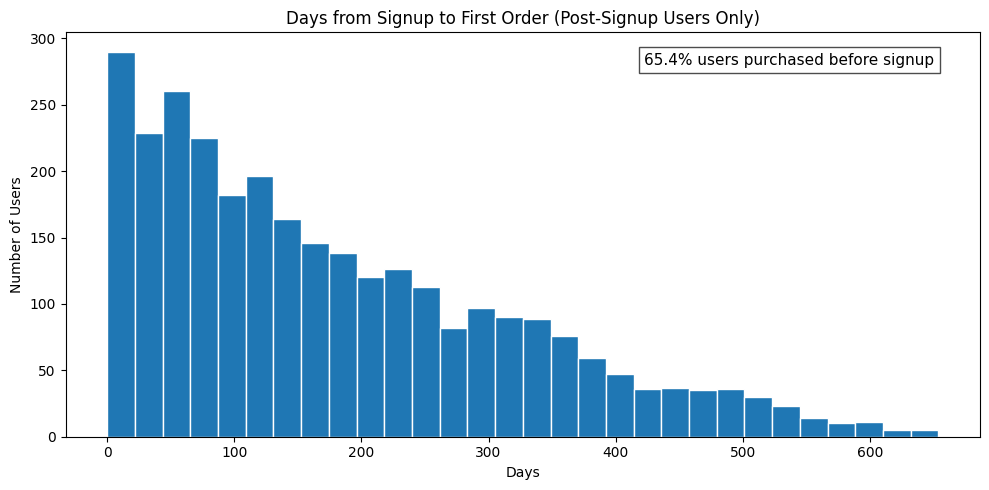

In [34]:
first_order = (
    df.groupby('user_id')['order_date']
    .min()
    .reset_index()
)

signup = df[['user_id', 'signup_date']].drop_duplicates()

time_to_buy = pd.merge(signup, first_order, on='user_id')

time_to_buy['days_to_first_order'] = (
    (time_to_buy['order_date'] - time_to_buy['signup_date']).dt.days
)


neg_mask = time_to_buy['days_to_first_order'] < 0
neg_pct = neg_mask.mean()

positive = time_to_buy[~neg_mask]
+
print(f"Total users: {len(time_to_buy)}")
print(f"Pre-signup buyers: {neg_pct:.1%}")
print(f"Post-signup users: {(1 - neg_pct):.1%}")
print(f"Avg days (valid users only): {positive['days_to_first_order'].mean():.1f}")

# --- Step 4: Plot histogram (only valid users) ---

plt.figure(figsize=(10, 5))

ax = positive['days_to_first_order'].plot(
    kind='hist',
    bins=30,
    edgecolor='white'
)

plt.title('Days from Signup to First Order (Post-Signup Users Only)')
plt.xlabel('Days')
plt.ylabel('Number of Users')

# --- Step 5: Add annotation for negative users ---

plt.text(
    0.95, 0.95,
    f"{neg_pct:.1%} users purchased before signup",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.tight_layout()
plt.show()

**Insight**: A significant 63% of users placed their first order before signing up, indicating that purchase often precedes account creation in this flow. For the remaining 37% of users (post-signup buyers), the distribution of days to first order is right-skewed: while many convert shortly after signing up (with a median close to 0 days), the average (~62.3 days) is much higher due to a long tail of users who delay their first purchase. This highlights two distinct user journeys—immediate converters and late adopters—pulling the mean upward.

## Repeat Purchase Rate

Repeat Purchase Rate: 67.47%


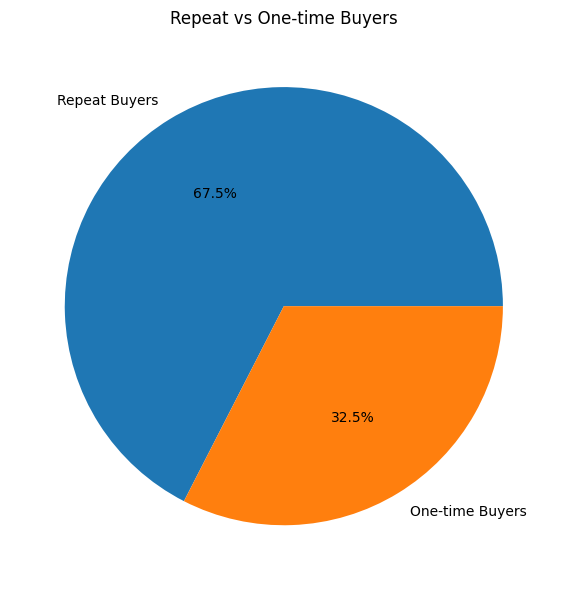

In [20]:
orders_per_user = df.groupby('user_id')['order_id'].nunique()
repeat_buyers   = orders_per_user[orders_per_user > 1].count()
total_buyers    = orders_per_user.count()
one_time_buyers = total_buyers - repeat_buyers

rpr = repeat_buyers / total_buyers
print(f"Repeat Purchase Rate: {rpr:.2%}")

pd.Series({
    'Repeat Buyers':   repeat_buyers,
    'One-time Buyers': one_time_buyers
}).plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), ylabel='')
plt.title('Repeat vs One-time Buyers')
plt.tight_layout()
plt.show()

> **Insight:** **67.5% of buyers made more than one purchase** (5,798 repeat buyers vs 2,796 one-time buyers). This is a strong retention signal — the majority of customers return. The focus should be on converting the remaining 32.5% one-time buyers into repeat customers.

## High Line-Item Value, Low Rating — by Category

,item_total,rating
category,,
Electronics,837279.22,2.759915
Automotive,523080.60,2.692531
Home & Kitchen,146751.14,2.728699
Sports,110482.51,2.752417
Clothing,43900.61,2.744078
Beauty,25357.53,2.736719
Pet Supplies,5494.68,2.625000
Toys,4835.49,2.790000
Books,1349.64,2.855000


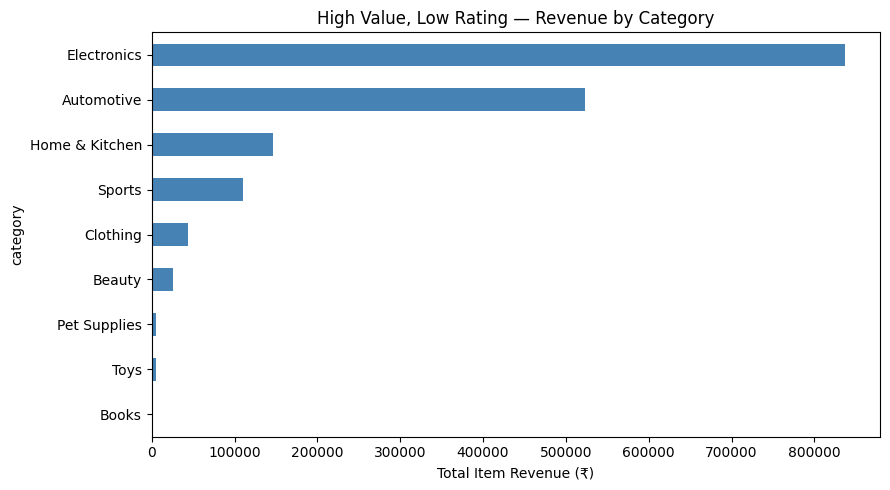

In [21]:
avg_item_total = df['item_total'].mean()

high_val_low_rating = (
    df[(df['item_total'] > avg_item_total) & (df['rating'] < 3)]
    .groupby('category')
    .agg(item_total=('item_total', 'sum'), rating=('rating', 'mean'))
    .sort_values('item_total', ascending=False)
)

display(high_val_low_rating)

high_val_low_rating['item_total'].plot(
    kind='barh', figsize=(9, 5), color='steelblue'
)
plt.title('High Value, Low Rating — Revenue by Category')
plt.xlabel('Total Item Revenue (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> **Insight:** **Electronics** is the most concerning category — highest revenue among high-value, low-rated items (₹8,37,279) with an average rating of just **2.76 / 5**. 9 out of 10 categories appear in this list, suggesting a broad quality or expectation mismatch across the catalogue rather than an isolated issue.

## Products Bought More Than Once by Same User

,user_id
product_name,
Zenith Rate,2
Acme Arrive,1
Acme Democratic,1
Acme Part,1
Acme Pm,1
Acme Board,1
Astra Great,1
Astra Key,1
Astra Last,1


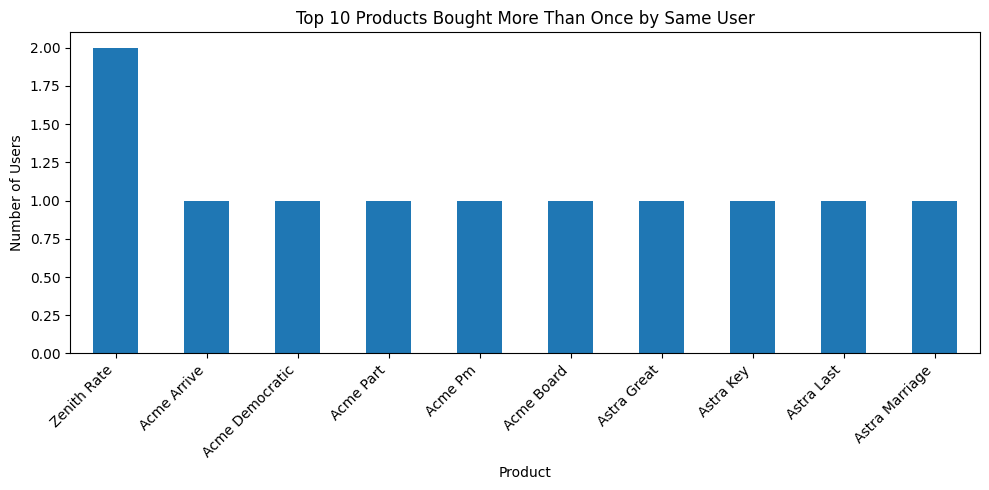

In [22]:
product_user_orders = df.groupby(['user_id', 'product_name'])['order_id'].nunique()

repeat_product_buyers = (
    product_user_orders[product_user_orders > 1]
    .reset_index()
    .groupby('product_name')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

display(repeat_product_buyers.head(10))

repeat_product_buyers.head(10).plot(kind='bar', figsize=(10, 5))
plt.title('Top 10 Products Bought More Than Once by Same User')
plt.ylabel('Number of Users')
plt.xlabel('Product')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** Very few users re-purchase the exact same product — the top repeated product (Zenith Rate) was bought again by only **2 users**. This suggests customers prefer variety over loyalty to specific products, which aligns with the long-tail revenue distribution seen earlier.

## High Views, Low Conversion Products

`events` is analysed separately — not merged into `df` — to avoid row duplication.

,purchase,view,conversion_rate
product_name,,,
Nimbus Threat,1,46,0.021739
GreenLeaf Visit,3,42,0.071429
Willow Cultural,2,42,0.047619
Harbor Eye,1,42,0.023810
Everest School,2,42,0.047619
Zenith Team,3,42,0.071429
Orion Medical,1,42,0.023810
Zenith Black,2,41,0.048780
Everest Easy,2,41,0.048780


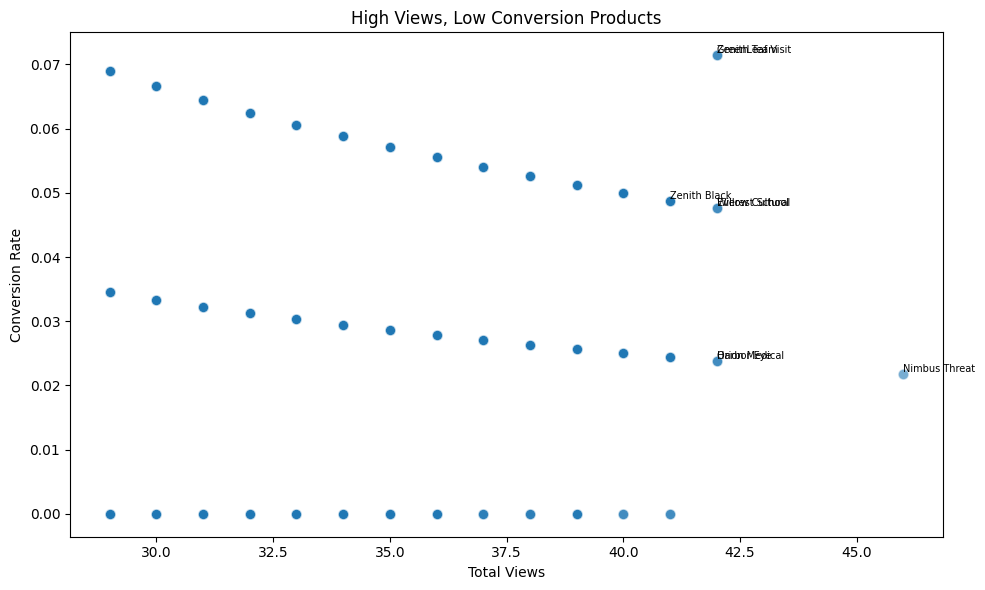

In [23]:
view_purchase = (
    events[events['event_type'].isin(['view', 'purchase'])]
    .groupby(['product_id', 'event_type'])['user_id']
    .count()
    .unstack(fill_value=0)
)

view_purchase['conversion_rate'] = view_purchase['purchase'] / view_purchase['view']

high_view_low_conv = view_purchase[
    (view_purchase['view'] > view_purchase['view'].mean()) &
    (view_purchase['conversion_rate'] < view_purchase['conversion_rate'].mean())
].sort_values(by='view', ascending=False)

product_name_map = df[['product_id', 'product_name']].drop_duplicates().set_index('product_id')
high_view_low_conv = high_view_low_conv.join(product_name_map).set_index('product_name')

display(high_view_low_conv.head(10))

# Scatter: views vs conversion rate — highlights high traffic, low converting products
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(high_view_low_conv['view'], high_view_low_conv['conversion_rate'],
           alpha=0.6, edgecolors='white', s=60)
ax.set_xlabel('Total Views')
ax.set_ylabel('Conversion Rate')
ax.set_title('High Views, Low Conversion Products')
# Label top 8 by views
for name, row in high_view_low_conv.head(8).iterrows():
    ax.annotate(name[:20], (row['view'], row['conversion_rate']),
                fontsize=7, ha='left', va='bottom')
plt.tight_layout()
plt.show()

> **Insight:** Products like **Nimbus Threat** and **Harbor Eye** attract high traffic (40+ views) but convert at only **2–3%**, well below average. These products likely have a listing or pricing problem — good discoverability but something is stopping purchase. Check their price, images, and description for friction points.

## Product Funnel: View → Cart → Purchase

,cart,purchase,view,cart_conversion_rate,purchase_conversion_rate
product_name,,,,,
Pulse Possible,6,8,33,0.181818,0.242424
Pulse Interesting,8,8,27,0.296296,0.296296
Astra Many,4,7,33,0.121212,0.212121
Zenith Guy,4,7,30,0.133333,0.233333
Solace Different,8,7,27,0.296296,0.259259
Orion Trouble,5,7,26,0.192308,0.269231
Everest Manage,4,7,25,0.160000,0.280000
Zenith Center,7,6,27,0.259259,0.222222
Nimbus Approach,11,6,24,0.458333,0.250000


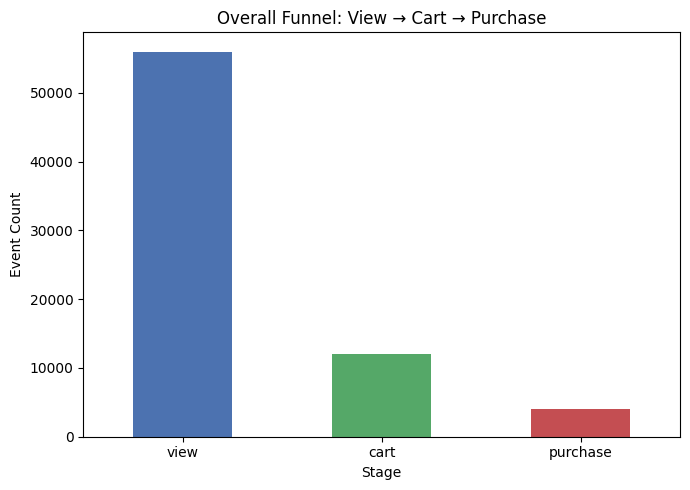

In [24]:
funnel = (
    events[events['event_type'].isin(['view', 'cart', 'purchase'])]
    .groupby(['product_id', 'event_type'])['user_id']
    .count()
    .unstack(fill_value=0)
)

funnel['cart_conversion_rate']     = funnel['cart']     / funnel['view']
funnel['purchase_conversion_rate'] = funnel['purchase'] / funnel['view']

product_name_map = df[['product_id', 'product_name']].drop_duplicates().set_index('product_id')
funnel = funnel.join(product_name_map).set_index('product_name')

display(funnel.sort_values(by='purchase', ascending=False).head(10))

# Overall funnel — total events at each stage
funnel_totals = events[events['event_type'].isin(['view', 'cart', 'purchase'])]     .groupby('event_type')['user_id'].count().reindex(['view', 'cart', 'purchase'])

funnel_totals.plot(kind='bar', figsize=(7, 5), color=['#4C72B0','#55A868','#C44E52'])
plt.title('Overall Funnel: View → Cart → Purchase')
plt.ylabel('Event Count')
plt.xlabel('Stage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **Insight:** Of **56,013 product views**, only 12,035 (21.5%) add to cart and just 4,006 (7.2%) result in a purchase. The biggest drop-off is **view → cart (78.5% drop)**, not cart → purchase (66.7% drop). This means the product page itself is the biggest conversion bottleneck — improving product pages will have more impact than optimising the checkout flow.

## Cities with High Revenue but Low User Count

,total_revenue,unique_users
city,,
Lake Alyssamouth,44286.70,1
Nolanborough,43466.35,1
Tylerland,43060.16,1
South Robertstad,40431.01,1
Savannahview,38943.29,1
...,...,...
Cervantesshire,4906.65,1
North Stephaniefort,4901.67,1
East Allenmouth,4896.76,1


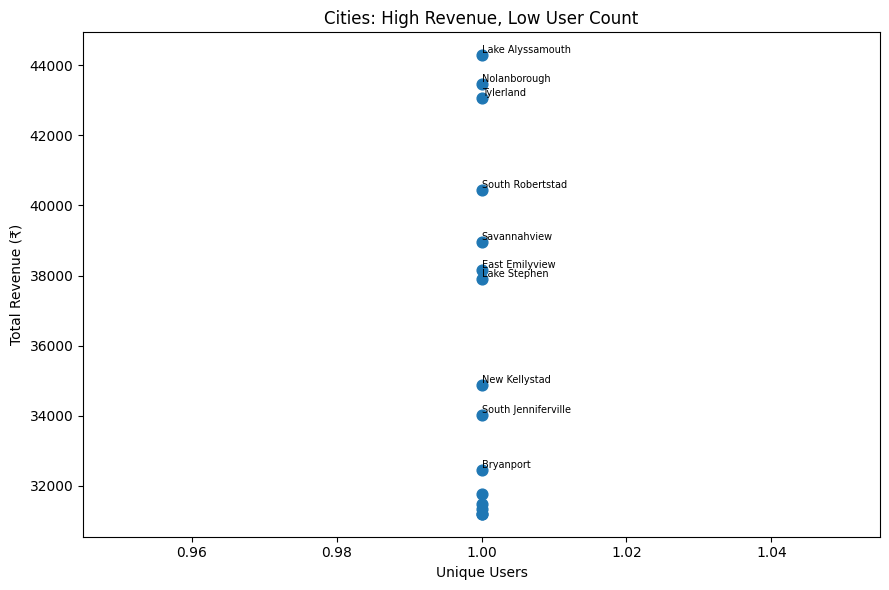

In [25]:
city_stats = df.groupby('city').agg(
    total_revenue=('total_amount', 'sum'),
    unique_users=('user_id',       'nunique')
)

high_rev_low_users = city_stats[
    (city_stats['total_revenue'] > city_stats['total_revenue'].mean()) &
    (city_stats['unique_users']  < city_stats['unique_users'].mean())
].sort_values(by='total_revenue', ascending=False)

display(high_rev_low_users)

high_rev_low_users.head(15).plot(
    x='unique_users', y='total_revenue', kind='scatter', figsize=(9, 6), s=60
)
plt.title('Cities: High Revenue, Low User Count')
plt.xlabel('Unique Users')
plt.ylabel('Total Revenue (₹)')
for city, row in high_rev_low_users.head(10).iterrows():
    plt.annotate(city, (row['unique_users'], row['total_revenue']),
                 fontsize=7, ha='left', va='bottom')
plt.tight_layout()
plt.show()

> **Insight:** 1,542 cities show high revenue despite having very few users (often just 1), with the top city (Lake Alyssamouth) generating ₹44,287 from a single user. These are likely high-value individual buyers in smaller cities — they represent an untapped market where targeted outreach could yield strong returns.

## Cities with High User Count but Low Engagement

,total_users,total_views
city,,
Josephborough,3,6.0
Ambertown,2,7.0
Ashleyton,2,6.0
Andersonstad,2,6.0
Brownberg,2,7.0


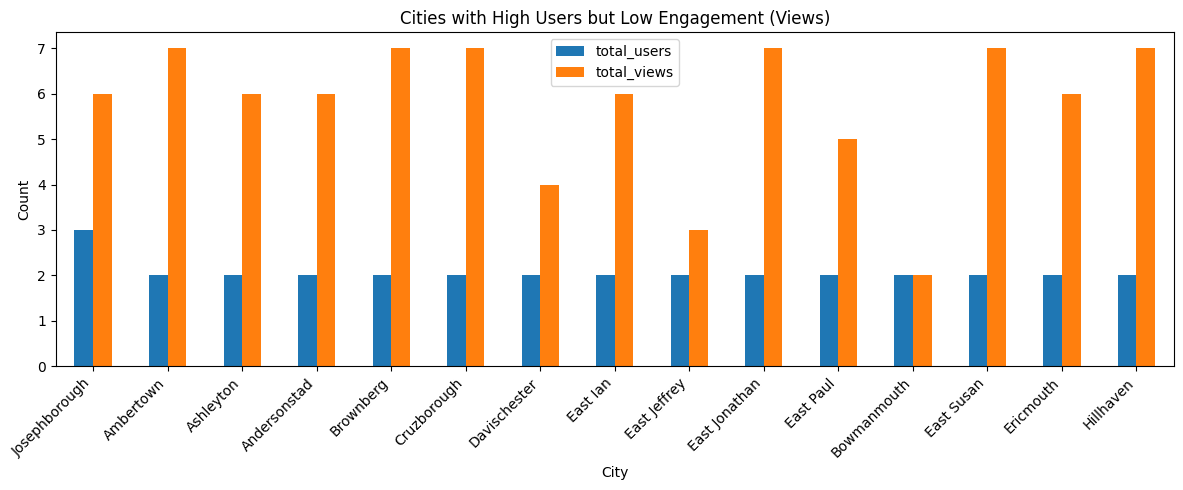

In [26]:
# event_type is not in df — events was kept separate to avoid row explosion
# so we pull views directly from events, map city via df
total_users_city = df.groupby('city')['user_id'].nunique().rename('total_users')

total_views_city = (
    events[events['event_type'] == 'view']
    .merge(df[['user_id', 'city']].drop_duplicates(), on='user_id')
    .groupby('city')['user_id']
    .count()
    .rename('total_views')
)

city_engagement = pd.concat([total_users_city, total_views_city], axis=1).dropna()

low_engagement = city_engagement[
    (city_engagement['total_views'] < city_engagement['total_views'].mean()) &
    (city_engagement['total_users'] > city_engagement['total_users'].mean())
].sort_values(by='total_users', ascending=False)

display(low_engagement.head())

low_engagement.head(15)[['total_users', 'total_views']].plot(
    kind='bar', figsize=(12, 5)
)
plt.title('Cities with High Users but Low Engagement (Views)')
plt.ylabel('Count')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** Several cities have a large registered user base but very low browsing activity. These users signed up but are not engaging with the product catalogue. Targeted re-engagement campaigns (email, push notifications) in these cities could unlock revenue from an already-acquired audience.